In [1]:
import os, sys
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\KAN_variants")
from ChebyKANLayer import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [2]:
def vanDerPoll(X, t, epsilon):
    x = X[0]
    y = X[1]
    dxdt = y
    dydt = epsilon*(1-x*x)*y - x
    return [dxdt, dydt]
vdpX0 = [0, 1.5]
vdpParams = [0.2]

In [3]:
model = ChebyKAN([2, 10, 2], 4)
kanODE = KANODE(model, vanDerPoll, vdpX0, vdpParams, 50, 20, 0.008)

In [ ]:
saveDirectory = os.path.join(module_path, "savedModels", "vdp3")
kanODE.train(-1, saveDirectory=saveDirectory, solverMethod="rk4", maxEpochs=5000, saveName="secondBatchLearn")
_, solution = kanODE.test(solverMethod="rk4")
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

 74%|███████▍  | 3699/5000 [14:26:48<5:17:55, 14.66s/it]

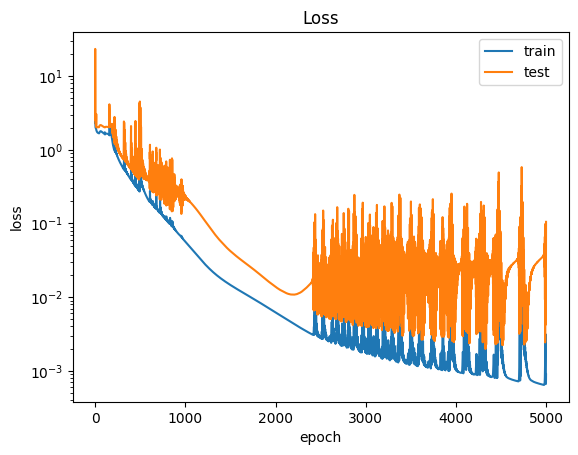

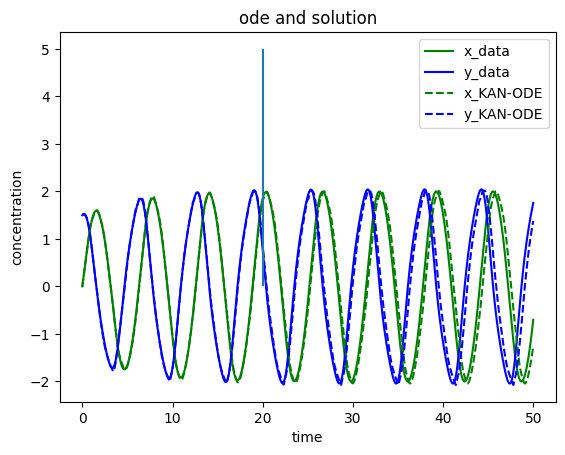

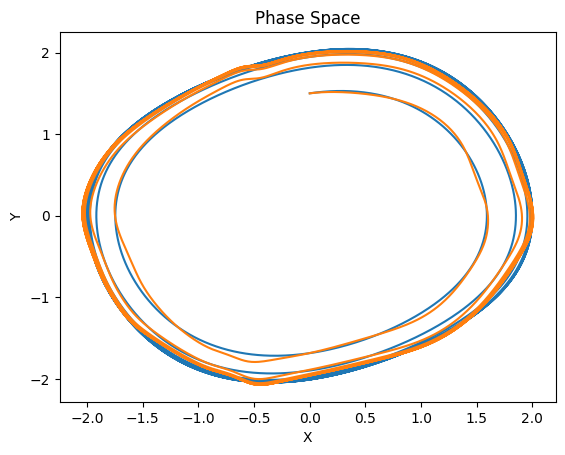

In [5]:
_, solution = kanODE.test(solverMethod="rk4")
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

In [6]:
solution

tensor([[[ 0.0000,  1.5000]],

        [[ 0.0118,  1.5020]],

        [[ 0.0235,  1.5038]],

        ...,

        [[-1.2849,  1.3599]],

        [[-1.2741,  1.3688]],

        [[-1.2633,  1.3778]]], grad_fn=<CopySlices>)